# Time Series Analysis of Economic Development Dynamics in Central America  
### First Notebook: Data Preparation and Exploratory Data Analysis (EDA)

This project aims to analyze long-term economic development dynamics in Central America through time series methods. It is based on the UN National Accounts Main Aggregates Database, providing consistent macroeconomic indicators across countries over several decades.

The dataset includes key macroeconomic variables such as Gross Domestic Product (GDP), GDP per capita, and gross capital formation, covering multiple countries in Central America over an extended historical period. These indicators allow for a structured analysis of long-term growth patterns, economic volatility, and cross-country development trajectories.

Unlike predictive machine learning problems, this project does not focus on building complex forecasting systems or clustering countries into predefined groups. The objective is instead to understand underlying temporal dynamics, identify structural trends, and analyze how economic trajectories evolve and diverge across countries within the region.

Particular attention is given to data cleaning, temporal consistency, and the construction of meaningful time-based features such as growth rates and lagged variables. These steps ensure that the time series structure is properly preserved and interpretable for economic analysis.

The overall goal is to generate insights relevant to development economics and policy analysis, particularly in relation to economic resilience, convergence patterns, and structural growth constraints in Central America. This first notebook focuses on preparing the dataset and conducting exploratory time series analysis to understand trends, distributions, and inter-country relationships over time. These steps provide the foundation for subsequent dynamic and econometric analyses.

**Author:** J-F Jutras  
**Date:** April 2026  
**Dataset:** UN National Accounts Main Aggregates Database (Central America subset)

## 1.1-Data Loading and Overview

In [1]:
import kagglehub
import pandas as pd
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("prasad22/global-economy-indicators")

print("Path to dataset files:", path)

# Define dataset path
dataset_dir = path

# Get CSV files
csv_files = [f for f in os.listdir(dataset_dir) if f.endswith(".csv")]

print("CSV files found:", csv_files)

# Load into df
df = pd.read_csv(os.path.join(dataset_dir, csv_files[0]))

# Clone utility repository
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
import sys
sys.path.append("/kaggle/working/jfj-utils")

Path to dataset files: /kaggle/input/datasets/prasad22/global-economy-indicators
CSV files found: ['Global Economy Indicators.csv']
Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (280/280), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 3527 (delta 224), reused 96 (delta 96), pack-reused 3247 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 16.14 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10512 entries, 0 to 10511
Data columns (total 26 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0    CountryID                                                                                  10512 non-null  int64  
 1    Country                                                                                    10512 non-null  object 
 2    Year                                                                                       10512 non-null  int64  
 3    AMA exchange rate                                                                          10512 non-null  float64
 4    IMF based exchange rate                                                                    10512 non-null  float64
 5    Population                            

### Project Scope Narrowing

This step focuses on restricting the dataset to Central American countries and selecting a subset of macroeconomic indicators relevant for time series analysis. By reducing dimensionality and keeping only meaningful variables, we ensure a clearer and more interpretable analysis of economic dynamics over time.

In [3]:
# Define Central American countries
central_america = [
    "Guatemala",
    "Belize",
    "El Salvador",
    "Honduras",
    "Nicaragua",
    "Costa Rica",
    "Panama"
]

# Filter dataset for selected countries
df.columns = df.columns.str.strip()
df["Country"] = df["Country"].str.strip()
df_ca = df[df["Country"].isin(central_america)].copy()

# Select relevant columns for time series analysis 
cols = [
    "Country",
    "Year",
    "Population",
    "Gross Domestic Product (GDP)",
    "Per capita GNI",
    "Gross capital formation",
    "Exports of goods and services",
    "Imports of goods and services",
    "Final consumption expenditure"
]

df_ca = df_ca[cols]

# Sort values to preserve time series structure
df_ca = df_ca.sort_values(["Country", "Year"]).reset_index(drop=True)

# Quick check
df_ca.head()

,Country,Year,Population,Gross Domestic Product (GDP),Per capita GNI,Gross capital formation,Exports of goods and services,Imports of goods and services,Final consumption expenditure
0,Belize,1970,120905,27917782.0,195,7450178.0,10317179.0,12335045.0,21072623.0
1,Belize,1971,123091,35385285.0,245,9299593.0,13474524.0,15709957.0,26315597.0
2,Belize,1972,125054,46000141.0,315,12422347.0,18383266.0,21233992.0,33738204.0
3,Belize,1973,126875,74809672.0,514,20028373.0,24555373.0,31414706.0,58898086.0
4,Belize,1974,128620,99801545.0,639,25015682.0,41368811.0,44947663.0,70891032.0


In [4]:
from eda.describe_structure import describe_structure
describe_structure(df_ca)


=== Numeric Columns ===

                               count          mean           std          min  \
Year                           364.0  1.995500e+03  1.502899e+01       1970.0   
Population                     364.0  4.815164e+06  3.568159e+06     120905.0   
Gross Domestic Product (GDP)   364.0  1.282470e+10  1.680423e+10   27917782.0   
Per capita GNI                 364.0  2.612497e+03  2.770665e+03        195.0   
Gross capital formation        364.0  2.841005e+09  4.245449e+09 -105872604.0   
Exports of goods and services  364.0  4.640523e+09  6.048490e+09   10317179.0   
Imports of goods and services  364.0  5.722921e+09  6.901550e+09   12335045.0   
Final consumption expenditure  364.0  1.105516e+10  1.439272e+10   21072623.0   

                                        25%           50%           75%  \
Year                           1.982750e+03  1.995500e+03  2.008250e+03   
Population                     2.606420e+06  4.305142e+06  6.123872e+06   
Gross Domestic Prod

The dataset covers 7 Central American countries over the period 1970–2021, providing a balanced panel suitable for time series analysis.

Substantial variation is observed over time across countries in terms of economic size, with GDP ranging from under 30 million to over 85 billion USD, highlighting strong structural disparities within the region.

Investment levels, measured by gross capital formation, exhibit high dispersion and even negative values in some cases, suggesting periods of economic contraction or disinvestment.

External sector indicators (exports and imports) also show significant heterogeneity, indicating varying degrees of openness and integration into global markets across countries.

## 1.2-EDA - Univariate Analysis

| Variable                      | Type    | Goal                                                                  |
| ----------------------------- | ------- | --------------------------------------------------------------------- |
| Population                    | Numeric | Understand population distribution and detect extreme values          |
| Gross Domestic Product (GDP)  | Numeric | Analyze economic size distribution and inequality across observations |
| Per capita GNI                | Numeric | Examine income distribution across countries and years                |
| Gross capital formation       | Numeric | Understand investment distribution and volatility                     |
| Exports of goods and services | Numeric | Assess export intensity distribution and asymmetry                    |
| Imports of goods and services | Numeric | Evaluate import dependency distribution                               |
| Final consumption expenditure | Numeric | Understand consumption structure and spread                           |


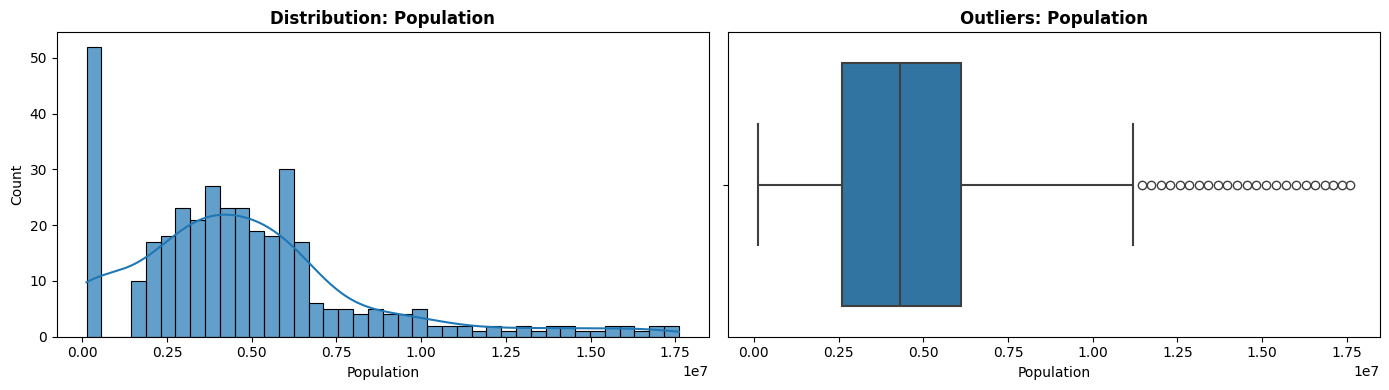

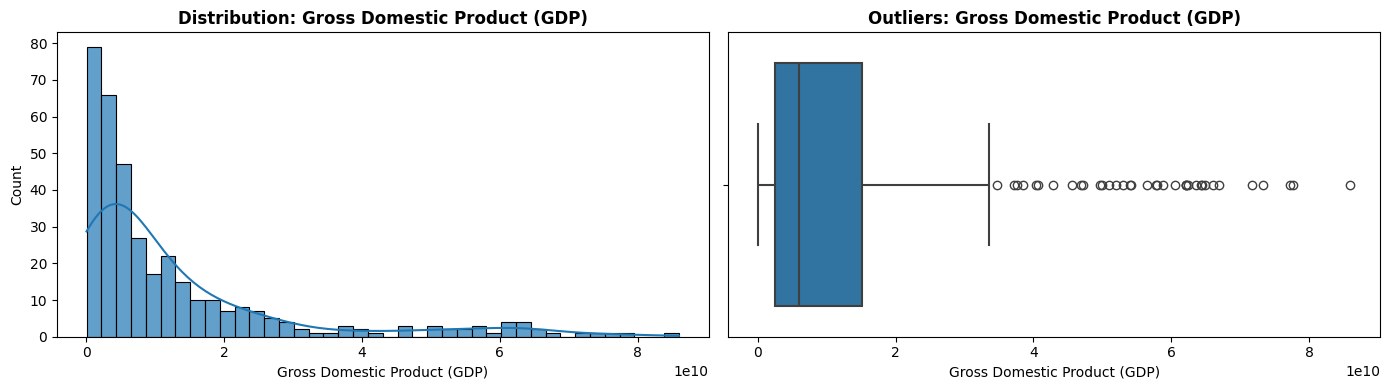

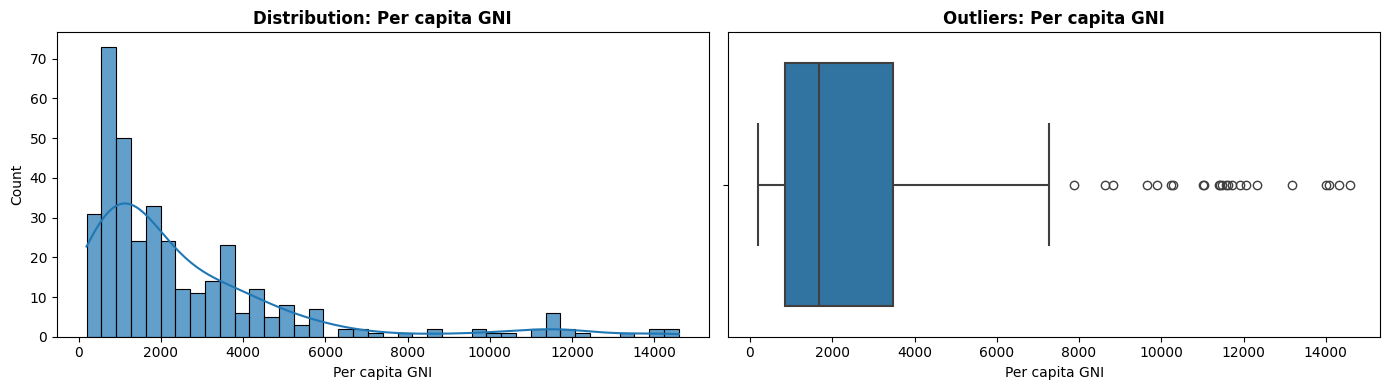

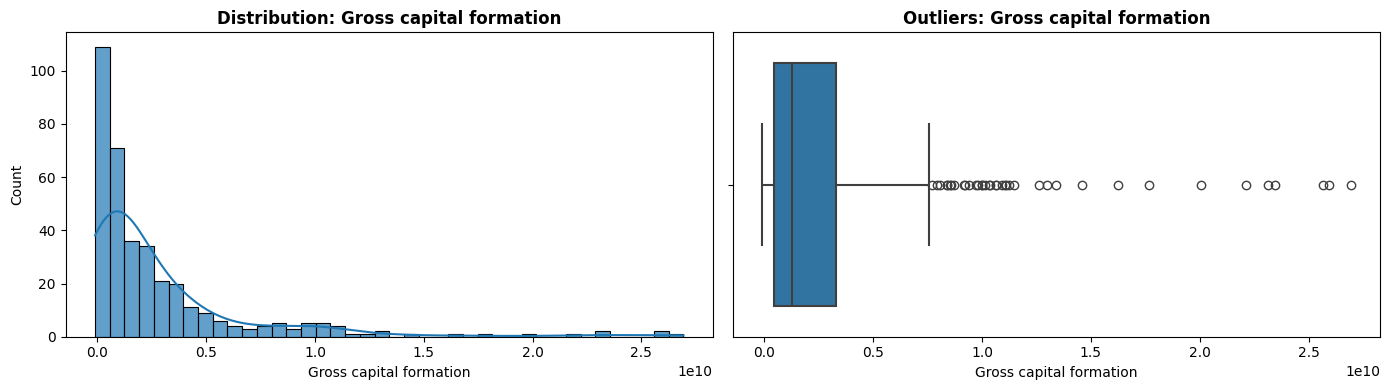

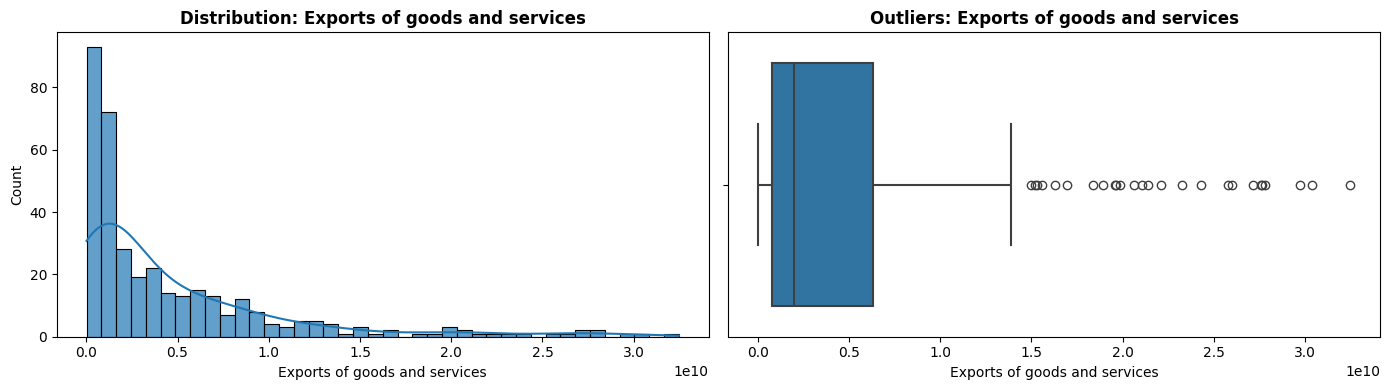

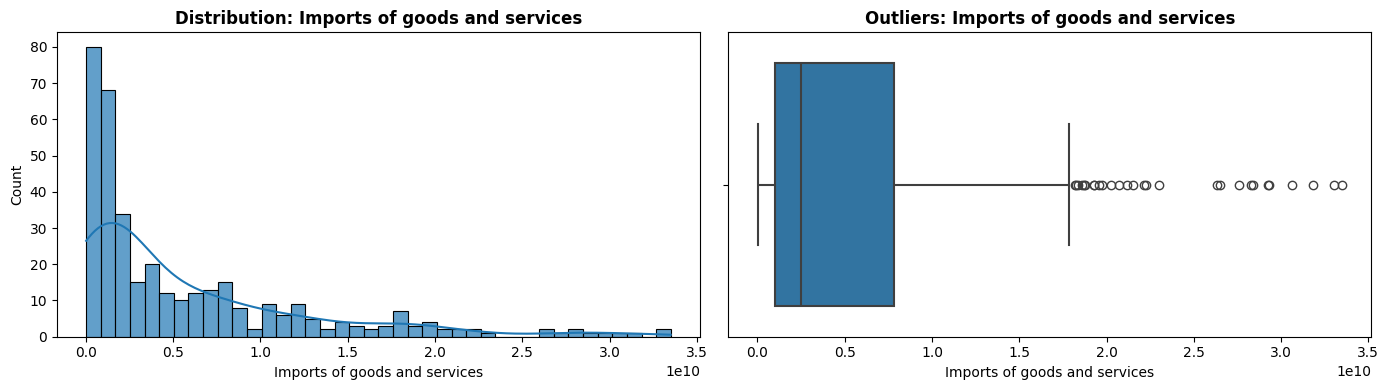

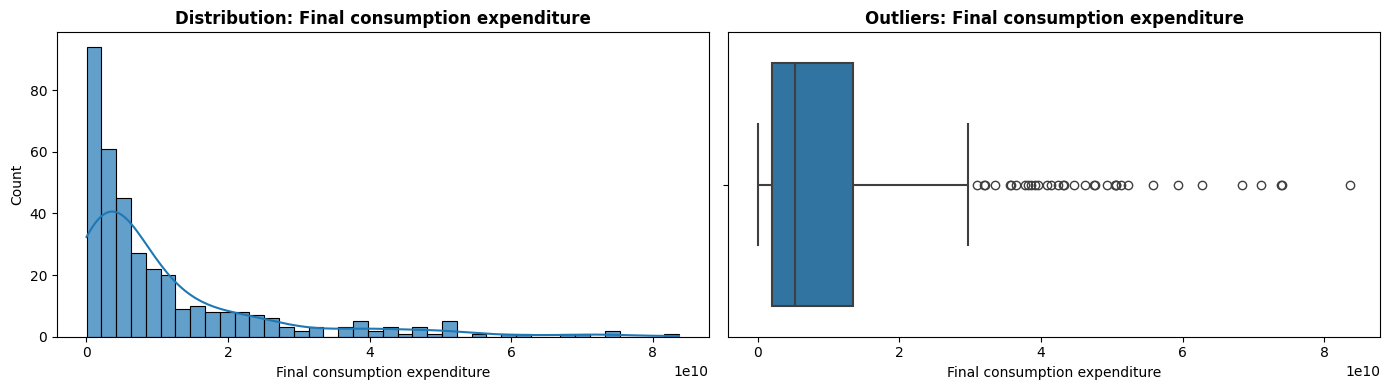

In [5]:
#Define columns to display
num_cols = ["Population", "Gross Domestic Product (GDP)", "Per capita GNI", "Gross capital formation",
    "Exports of goods and services", "Imports of goods and services", "Final consumption expenditure"]

from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(df_ca, num_cols)

The univariate distributions of all macroeconomic variables are highly right-skewed, indicating strong asymmetry in the observed economic values across countries and time. Most observations are concentrated at lower levels, while a small number of extreme values drive the upper tail of the distributions. This pattern reflects structural economic growth over time as well as inherent differences in scale across countries.

## 1.3-EDA - Bivariate Analysis

We now perform a bivariate analysis focusing on relationships between key macroeconomic variables. The objective is to examine how one economic indicator varies with respect to another (e.g., GDP vs investment, GDP vs trade, and GDP vs population). This step allows us to identify potential structural linkages in the data and understand whether certain macroeconomic variables move together in a systematic way. 

| Variable Pair                                  | Goal                                                                                  |
| ---------------------------------------------- | ------------------------------------------------------------------------------------- |
| GDP × Gross capital formation                  | Examine how investment levels are associated with economic output across observations |
| GDP × Exports of goods and services            | Assess the relationship between external demand and overall economic size             |
| GDP × Imports of goods and services            | Evaluate how import intensity varies with economic scale                              |
| GDP × Population                               | Understand whether economic output scales with demographic size                       |
| Final consumption expenditure × Per capita GNI | Investigate how income levels translate into consumption behavior                     |


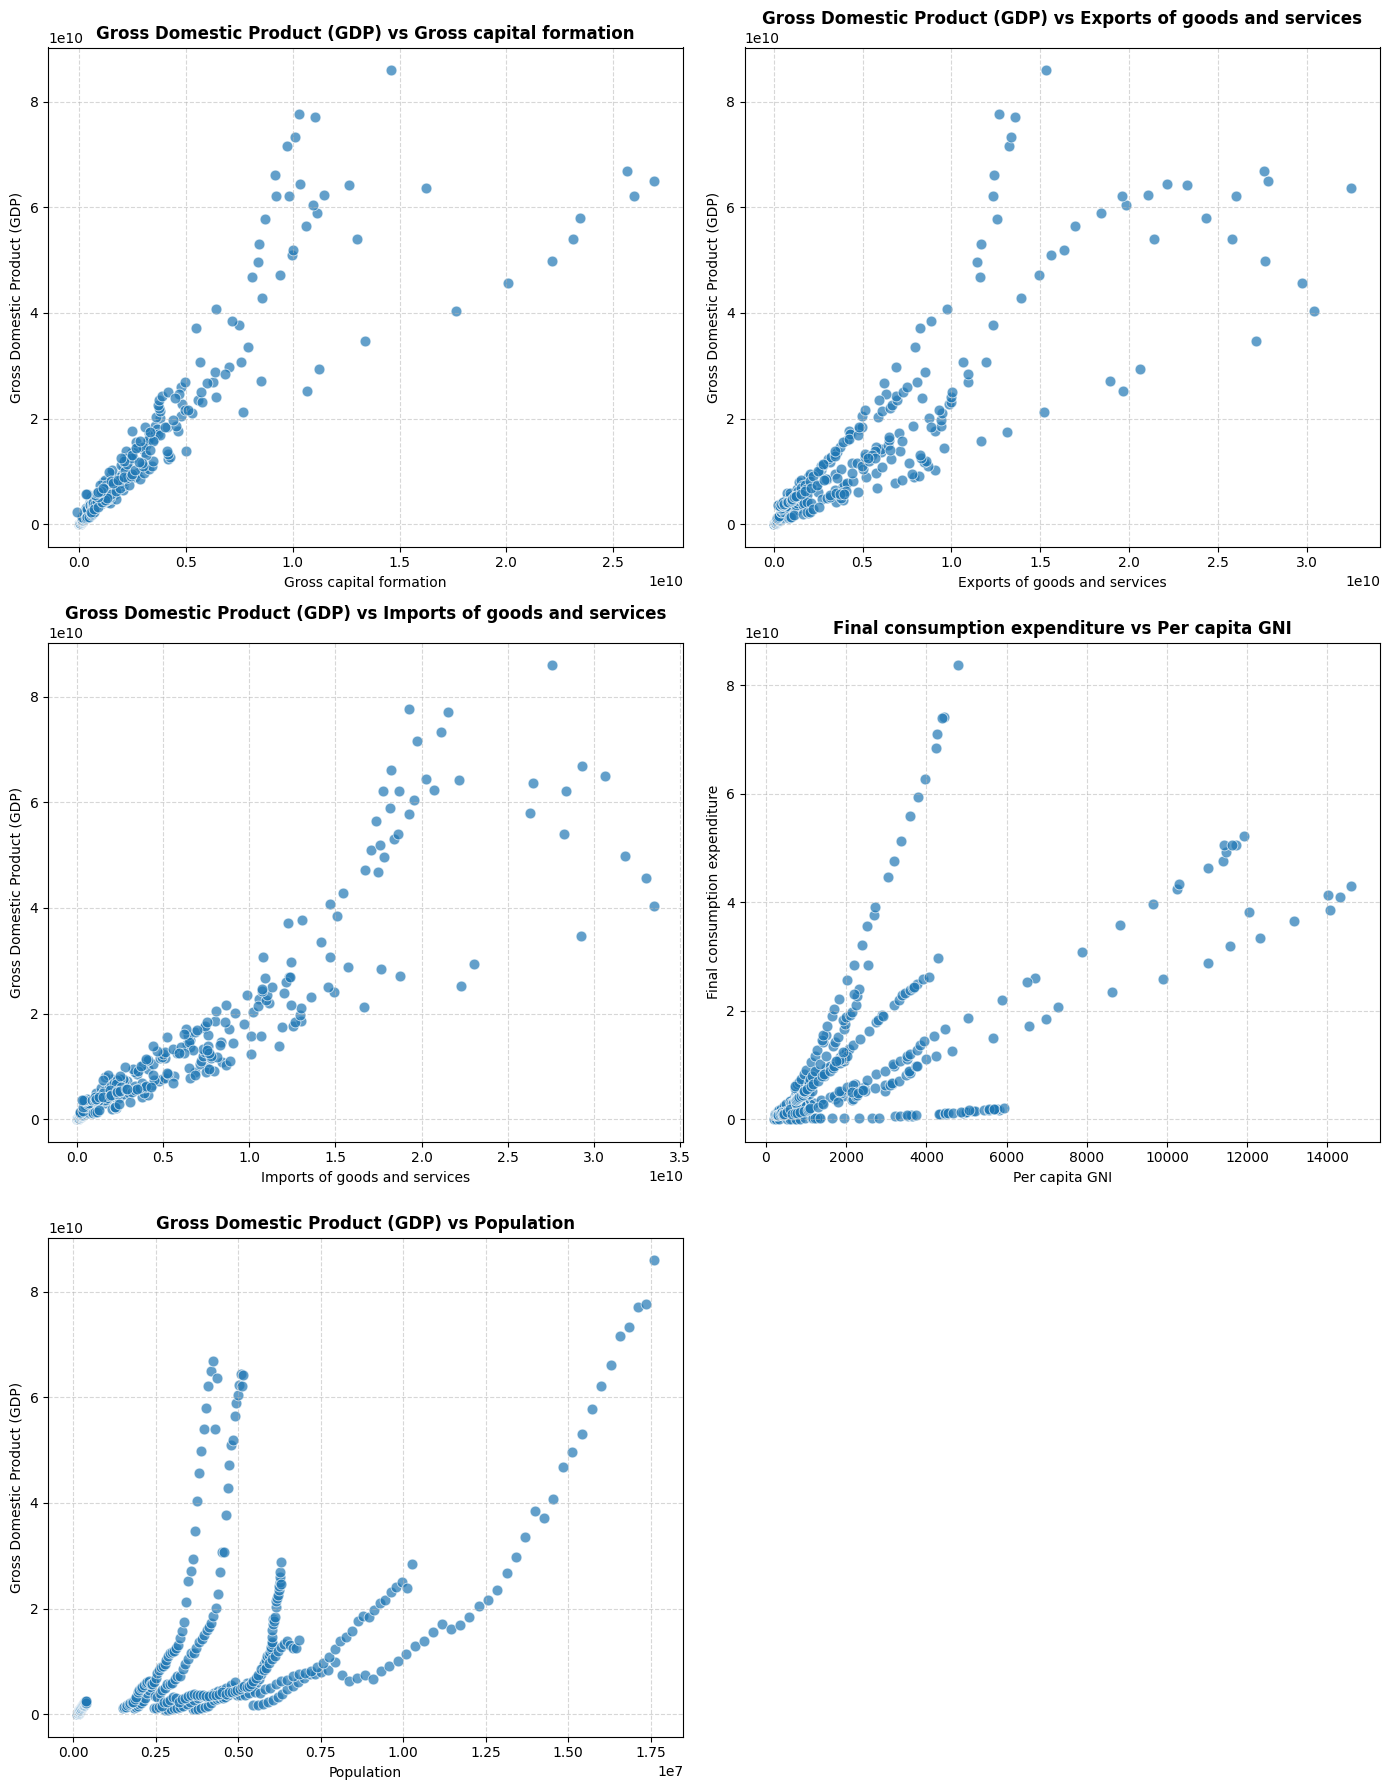

In [6]:
from visualization.explore_continuous import plot_scatter_grid

x_cols = [
    "Gross capital formation",
    "Exports of goods and services",
    "Imports of goods and services",
    "Per capita GNI",
    "Population"
]

y_cols = [
    "Gross Domestic Product (GDP)",
    "Gross Domestic Product (GDP)",
    "Gross Domestic Product (GDP)",
    "Final consumption expenditure",
    "Gross Domestic Product (GDP)"
]

plot_scatter_grid(
    df=df_ca,
    x_cols=x_cols,
    y_cols=y_cols,
    group_col=None
)

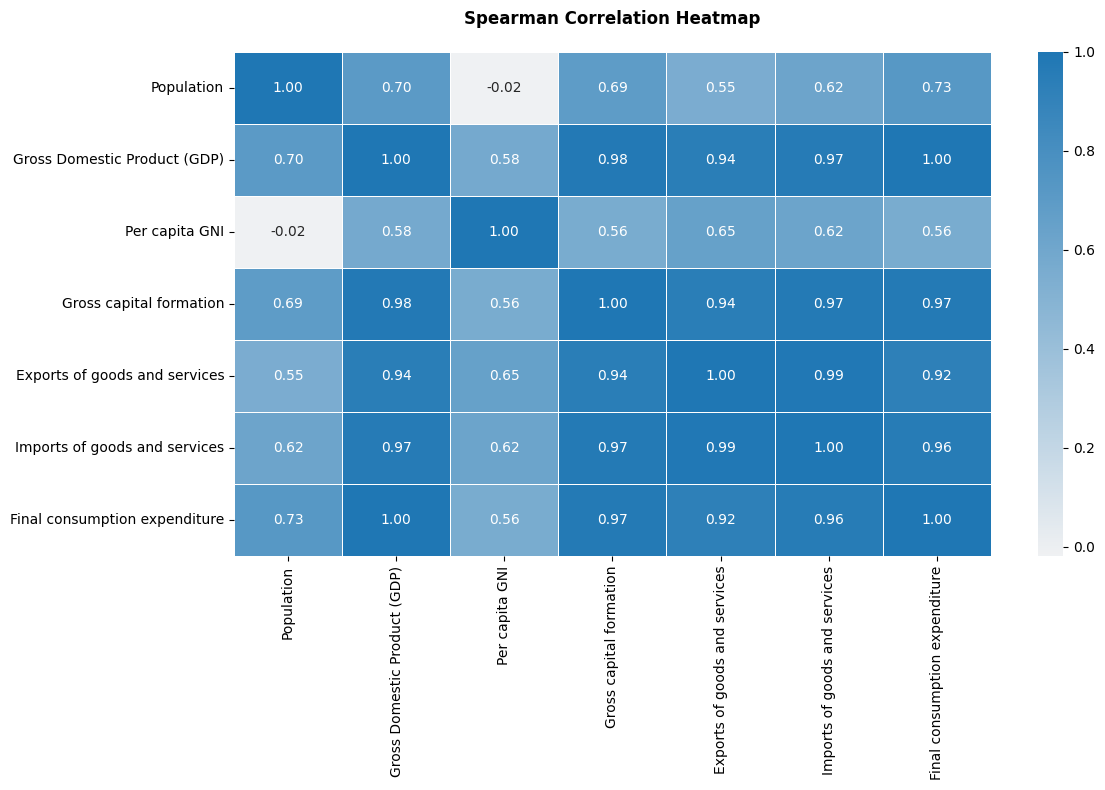

In [7]:
from visualization.explore_continuous import plot_correlation_heatmap
plot_correlation_heatmap(
    df=df_ca,
    numeric_cols=num_cols,
    method="spearman",
    figsize=(12,8),
)

### Bivariate Analysis - Summary

| Relationship                                   | Spearman Correlation | Strength         | Interpretation                                                                                                                                    |
| ---------------------------------------------- | -------------------- | ---------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- |
| GDP × Gross capital formation                  | 0.98                 | Extremely strong | Strong positive co-movement between GDP and gross capital formation, reflecting that both variables vary together across countries and over time. |
| GDP × Imports of goods and services            | 0.97                 | Extremely strong | Very strong association between GDP and imports, indicating that both variables tend to increase simultaneously across the panel.                 |
| GDP × Exports of goods and services            | 0.94                 | Very strong      | High positive co-variation between GDP and exports, showing that trade flows and economic size move together in the dataset.                      |
| GDP × Population                               | 0.70                 | Strong           | Positive association between population and GDP, with noticeable dispersion across countries and years.                                           |
| Final consumption expenditure × Per capita GNI | 0.56                 | Moderate         | Moderate positive association between income per capita and consumption expenditure, with substantial variability across observations.            |



## 1.4-EDA - Multivariate Analysis

We now perform a multivariate analysis focusing on joint economic performance across Central American countries. Unlike univariate and bivariate analyses, this step considers multiple macroeconomic indicators simultaneously in order to capture overall growth profiles, structural differences, and long-term development patterns across economies.

This section is purely descriptive and aims to synthesize cross-country heterogeneity using combined macroeconomic indicators such as growth rates, structural composition, and GDP evolution.

| Analysis Component                                                                      | Goal                                                                                                           |
| --------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| Country-level growth profiles (CAGR across GDP, income, investment, trade, consumption) | Compare long-term economic performance across countries using multiple macroeconomic indicators simultaneously |
| GDP evolution over time (multi-country comparison)                                      | Visualize long-term economic dynamics and relative divergence/convergence in GDP trajectories                  |
| Structural macroeconomic indicators over time (investment, trade, consumption, income)  | Examine the evolution of key economic components to understand the structural drivers behind growth patterns   |



| Country     | GDP Growth (CAGR) | GNI per Capita Growth | Investment Growth | Trade Growth | Consumption Growth | Insight (observational / hypothesis-based)                                                                                                                                                                           |
| ----------- | ----------------- | --------------------- | ----------------- | ------------ | ------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Belize      | ~0.09–0.10        | ~0.07                 | ~0.09             | ~0.09–0.10   | ~0.09              | Observed values are relatively high across multiple indicators compared to other countries, with noticeable variation over time. This may suggest a pattern of strong relative growth with variability.              |
| Costa Rica  | ~0.08             | ~0.06                 | ~0.085            | ~0.09        | ~0.075             | Indicators show consistently elevated growth values across variables over time, with relatively balanced levels across categories. This pattern could be consistent with relatively stable growth across indicators. |
| El Salvador | ~0.07             | ~0.06                 | ~0.08             | ~0.07–0.08   | ~0.07              | Growth values are moderate and relatively close across indicators, with limited dispersion between variables. This may indicate relatively uniform growth across macro indicators.                                   |
| Guatemala   | ~0.08             | ~0.056                | ~0.08             | ~0.07–0.08   | ~0.083             | GDP and consumption show slightly higher values relative to some other indicators, while other variables remain in similar ranges. This could suggest some heterogeneity across indicators.                          |
| Honduras    | ~0.07             | ~0.044                | ~0.076            | ~0.07–0.08   | ~0.075             | GNI per capita growth appears lower relative to other indicators, while other variables remain closer in range. This pattern may indicate divergence between income and other macro variables.                       |
| Nicaragua   | ~0.05–0.06        | ~0.03                 | ~0.06             | ~0.07–0.08   | ~0.054             | Most indicators show lower growth values compared to other countries, with some variability across variables. This could suggest generally lower observed growth levels in the dataset.                              |
| Panama      | ~0.08             | ~0.062                | ~0.081            | ~0.07–0.09   | ~0.077             | Indicators show relatively high and consistent values across multiple variables. This pattern may be consistent with broadly elevated growth levels across the observed period.                                      |


### GDP Evolution Over Time

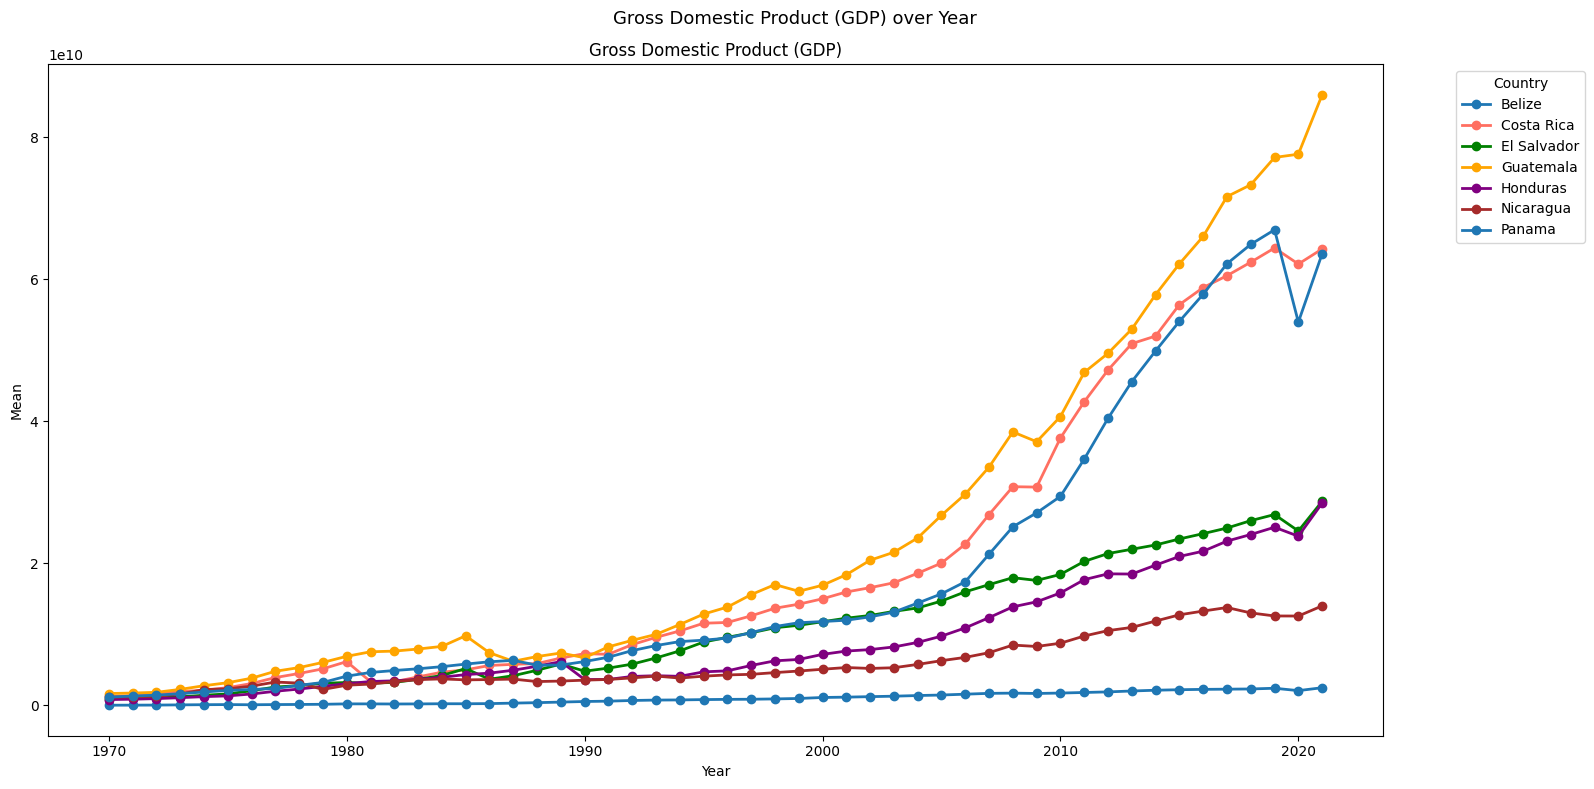

In [8]:
from visualization.explore_time import plot_line_grid_over_time

plot_line_grid_over_time(
    df_ca,
    value_cols="Gross Domestic Product (GDP)",
    time_col="Year",
    group_col="Country",
    figsize=(16,8)
)

Across the period, GDP shows an overall increasing trend in all Central American countries. Differences are observed between countries in terms of level and growth trajectory.

Costa Rica and Panama display strong and continuous upward trends over time, particularly from the 1990s onward. Guatemala also shows a sustained upward trend and reaches higher absolute GDP levels compared to some other countries in the region. Honduras, El Salvador, and Nicaragua show upward trends with more fluctuations over time, including periods of lower or interrupted growth. Belize shows a lower absolute GDP level compared to other countries, while still exhibiting an increasing trend over time.

Overall, GDP levels differ across countries, and all series show upward movement over the observed period even if the data shows a synchronized downturn in 2020 across all countries, followed by a recovery in 2021.

### Structural Macroeconomic Indicators Over Time

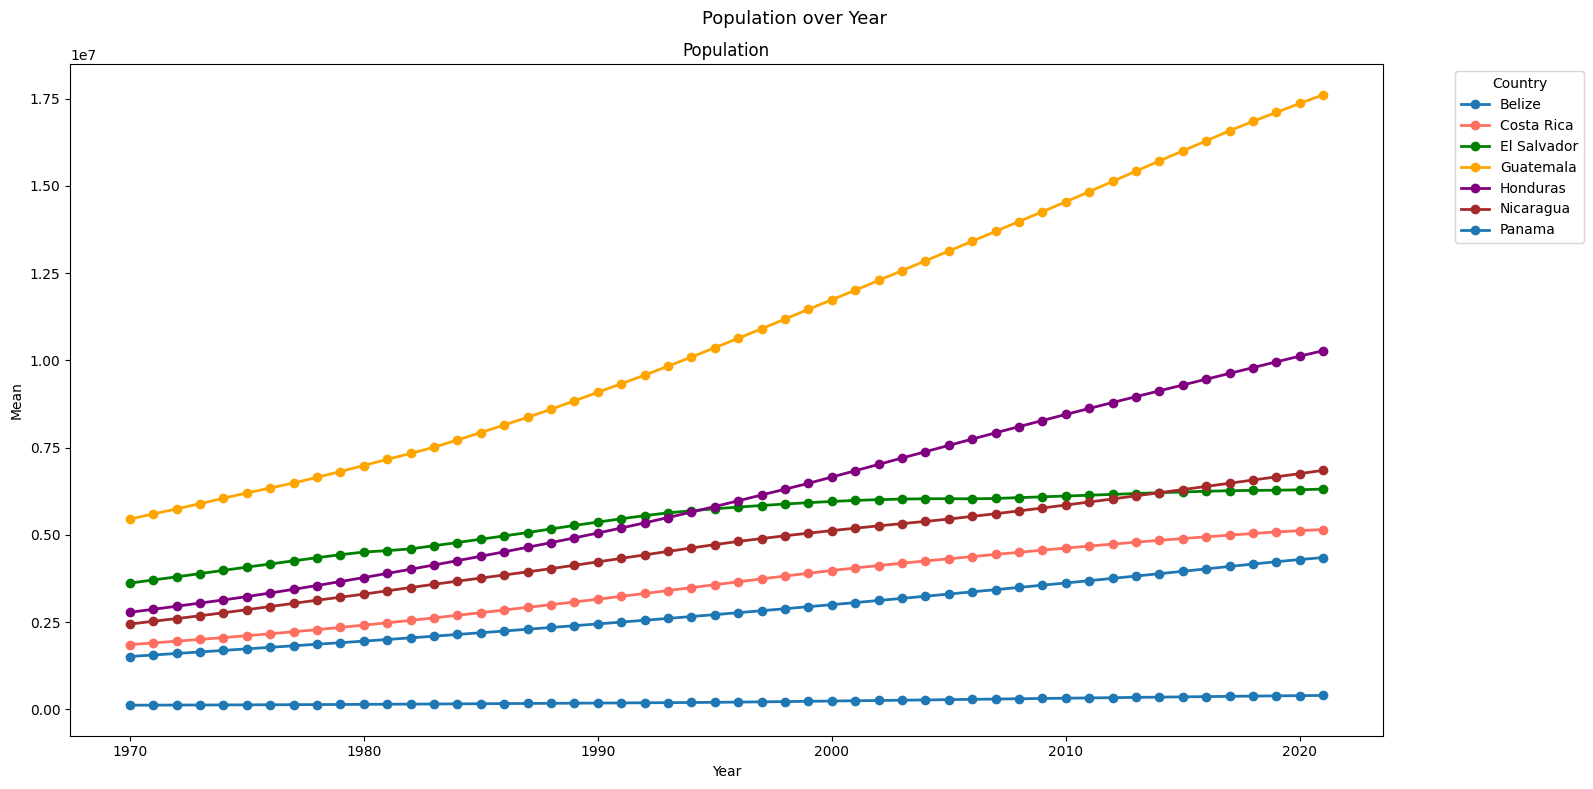

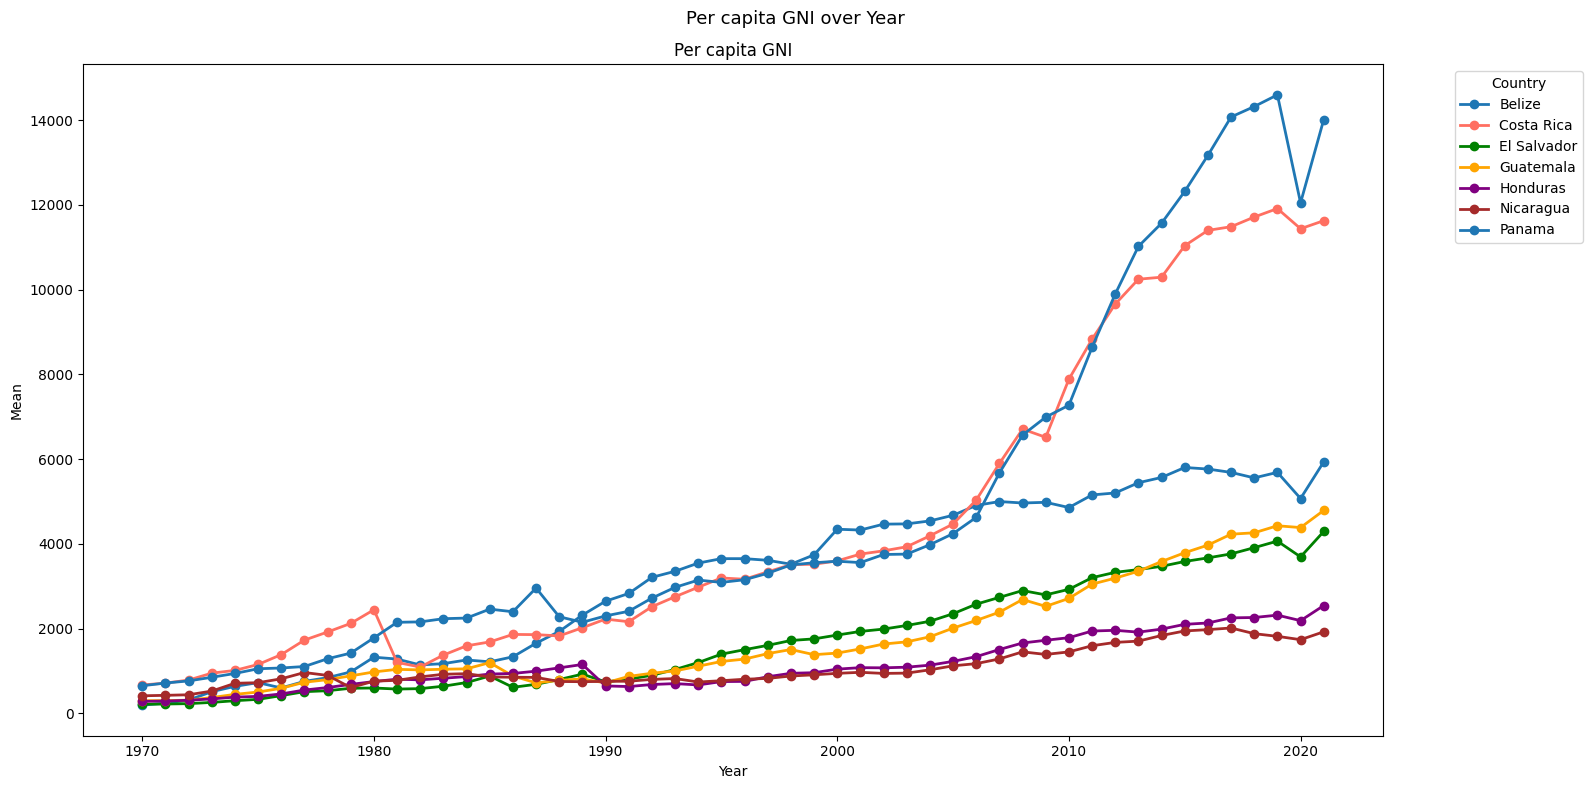

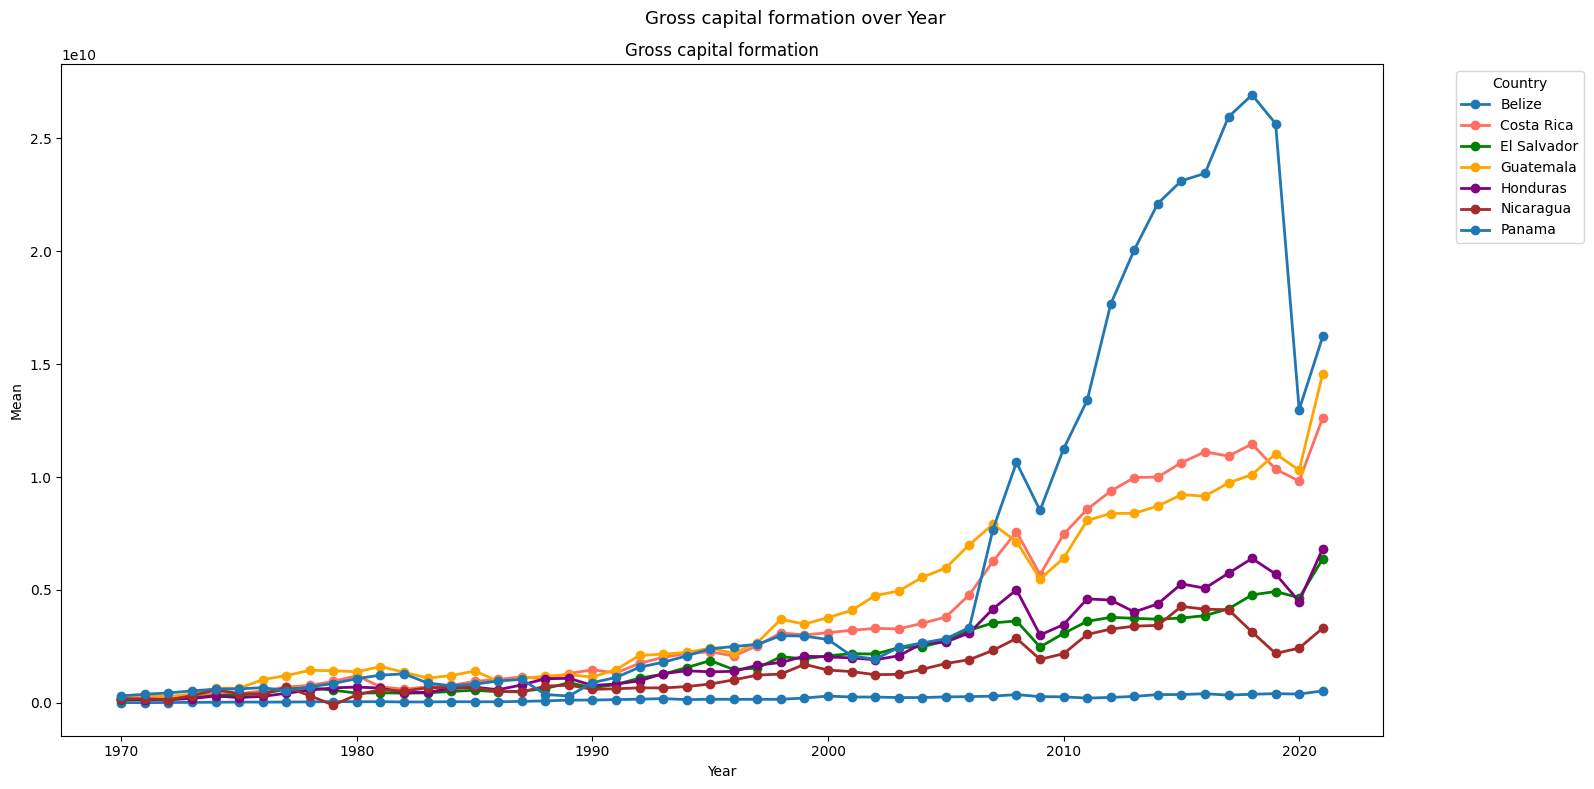

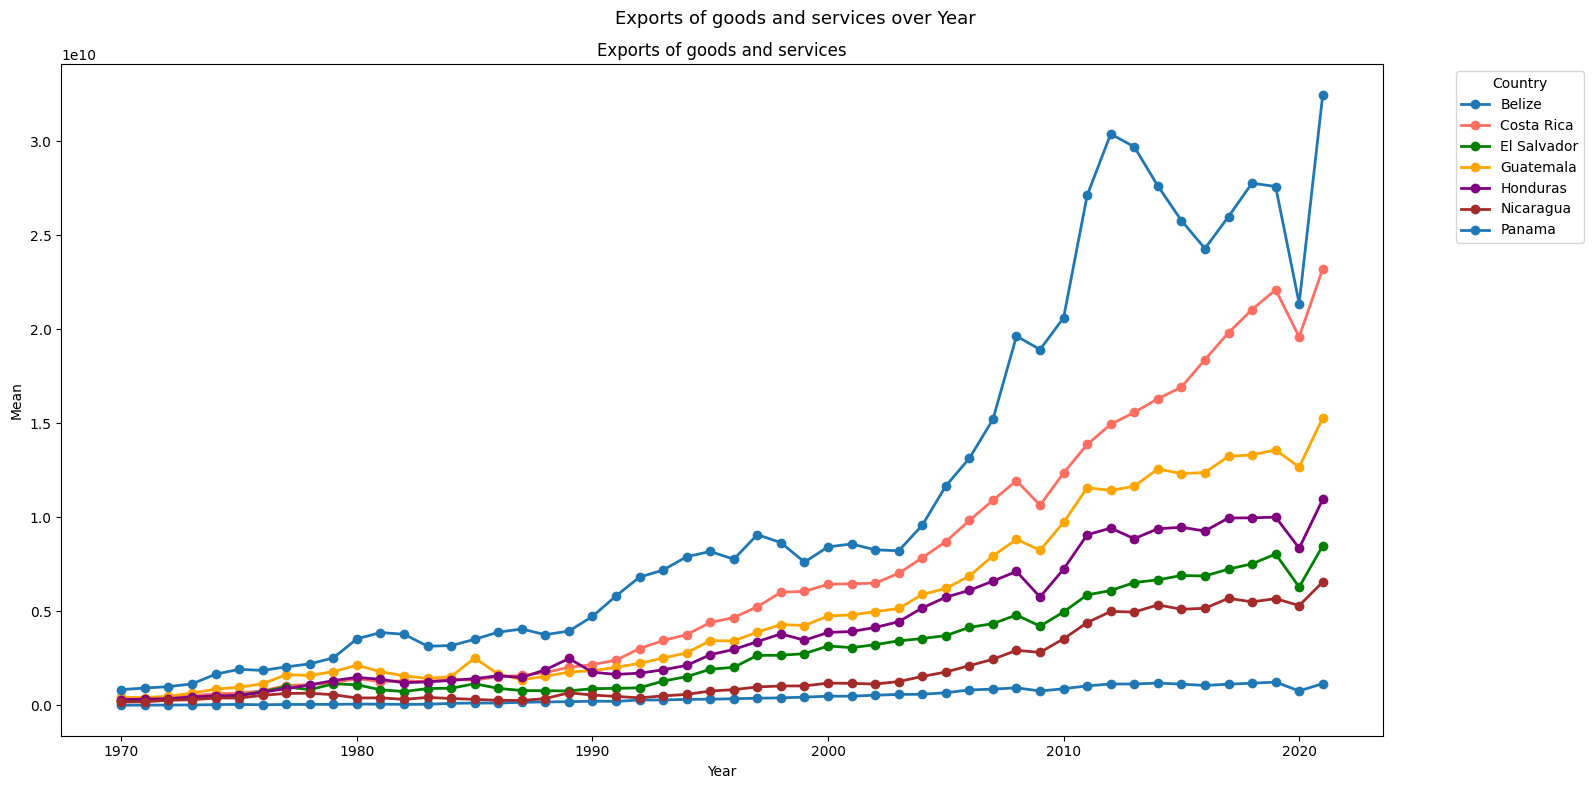

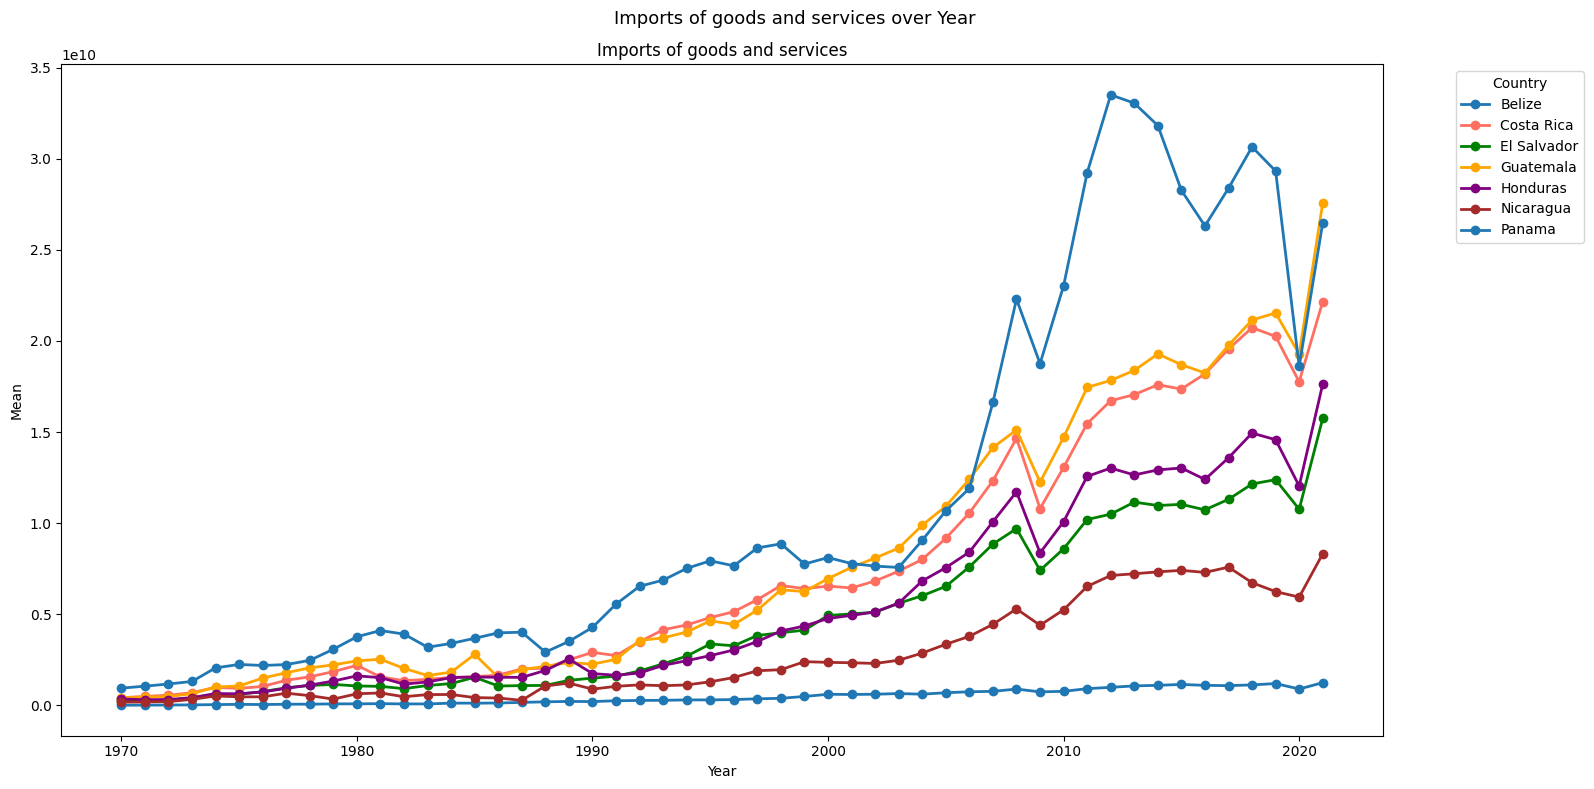

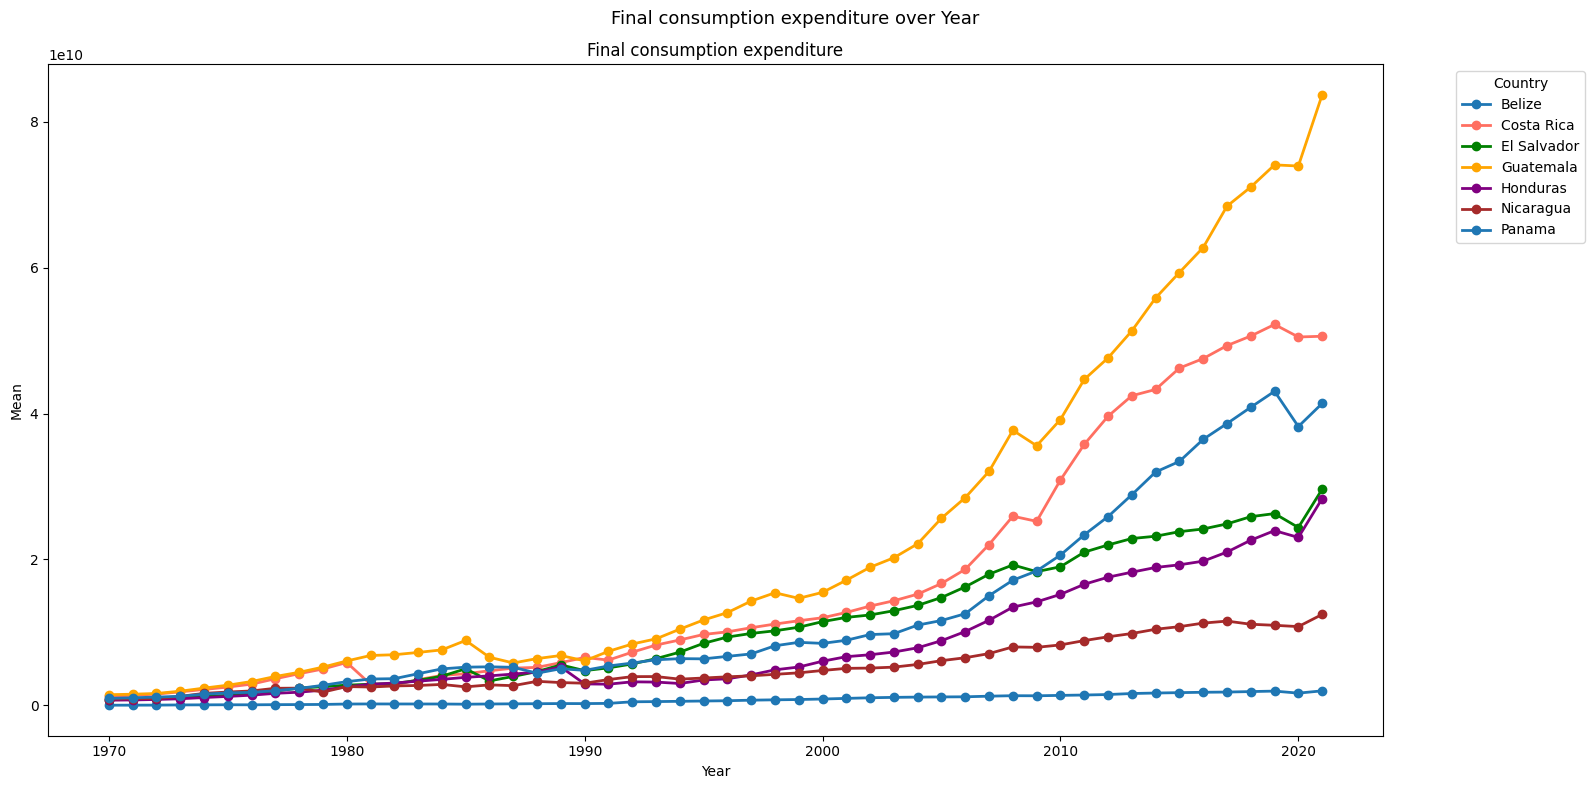

In [9]:
from visualization.explore_time import plot_line_grid_over_time

indicators = [
    "Population",
    "Per capita GNI",
    "Gross capital formation",
    "Exports of goods and services",
    "Imports of goods and services",
    "Final consumption expenditure"
]

for ind in indicators:
    plot_line_grid_over_time(
        df_ca,
        value_cols=ind,
        time_col="Year",
        group_col="Country",
        figsize=(16, 8)
    )

| Country     | Per capita GNI                              | Investment (GFCF)                                    | Exports                                    | Imports                           | Consumption                             |
| ----------- | ------------------------------------------- | ---------------------------------------------------- | ------------------------------------------ | --------------------------------- | --------------------------------------- |
| Belize      | Increasing trend over time with variability | High variability across the period with fluctuations | Low levels with gradual increase over time | Increasing trend over time        | Relatively stable with gradual increase |
| Costa Rica  | Strong upward trend over time               | Consistent increase in later years                   | Strong upward trend over time              | Increasing trend over time        | Stable upward trend                     |
| El Salvador | Moderate upward trend over time             | Low growth with limited variation                    | Low levels with slow increase              | Stable increasing trend           | Moderate upward trend                   |
| Guatemala   | Moderate upward trend with fluctuations     | Increasing trend with variability                    | Gradual increase over time                 | Increasing trend over time        | Strong upward trend                     |
| Honduras    | Slow upward trend over time                 | Moderate variability over time                       | Stable low-level growth                    | Increasing trend over time        | Stable moderate growth                  |
| Nicaragua   | Weak upward trend over time                 | Low and volatile pattern                             | Low and unstable levels                    | Increasing trend over time        | Slow upward trend                       |
| Panama      | Strong upward trend over time               | Strong upward trend over time                        | Strong upward trend over time              | High levels with increasing trend | Strong upward trend                     |

**Again, it should be noted that data shows a synchronized downturn in 2020 across all countries and macroeconomic indicators, followed by a recovery in 2021.**

## 1.5-Summary - Notebook 1

| Dimension             | EDA Result                                                             | Insight                                                            |
| --------------------- | ----------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| Dataset structure     | 7 Central American countries, 1970–2021, balanced panel                             | Provides consistent longitudinal coverage across countries                    |
| Economic scale        | GDP ranges from millions to tens of billions USD across observations                | Strong heterogeneity in economic size across countries and time               |
| Distributions         | All macro variables are highly right-skewed                                         | Indicates concentration of observations at lower levels with few large values |
| Time evolution        | All countries show upward trends in GDP, income, investment, trade, and consumption | Series are predominantly trend-driven over time                               |
| GDP dynamics          | Costa Rica and Panama show stronger and smoother increases; others more fluctuating | Differences in GDP trajectories are mainly in stability and amplitude         |
| Correlations          | Very strong correlations between GDP, investment, imports, and exports (≈0.94–0.98) | Macro variables move jointly across the panel                                 |
| Income vs consumption | Moderate relationship between GNI per capita and consumption (~0.56)                | Consumption responds only partially to income variation                       |
| Data quality          | Limited missing data after filtering; some volatility in investment series          | Dataset is sufficiently clean for exploratory time series analysis            |


## 1.6-Data Export

In [10]:
import os

file_name = "central_america_timeseries_eda.csv"
df_ca.to_csv(file_name, index=False)

print("CSV export completed")
print(f"File saved as: {file_name}")
print("File exists:", os.path.exists(file_name))
print("File size (KB):", round(os.path.getsize(file_name) / 1024, 2))

CSV export completed
File saved as: central_america_timeseries_eda.csv
File exists: True
File size (KB): 32.8
